In [5]:
import os
import json
import cv2
import glob
from ultralytics import YOLO
from pycocotools import mask as mask_utils
from tidecv import TIDE, datasets
from IPython.display import Image, display


COCO JSON created!
-- pred --

mask AP @ 50: 94.18

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     4.39     0.00     0.10     0.92     0.00  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       3.84       1.74  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

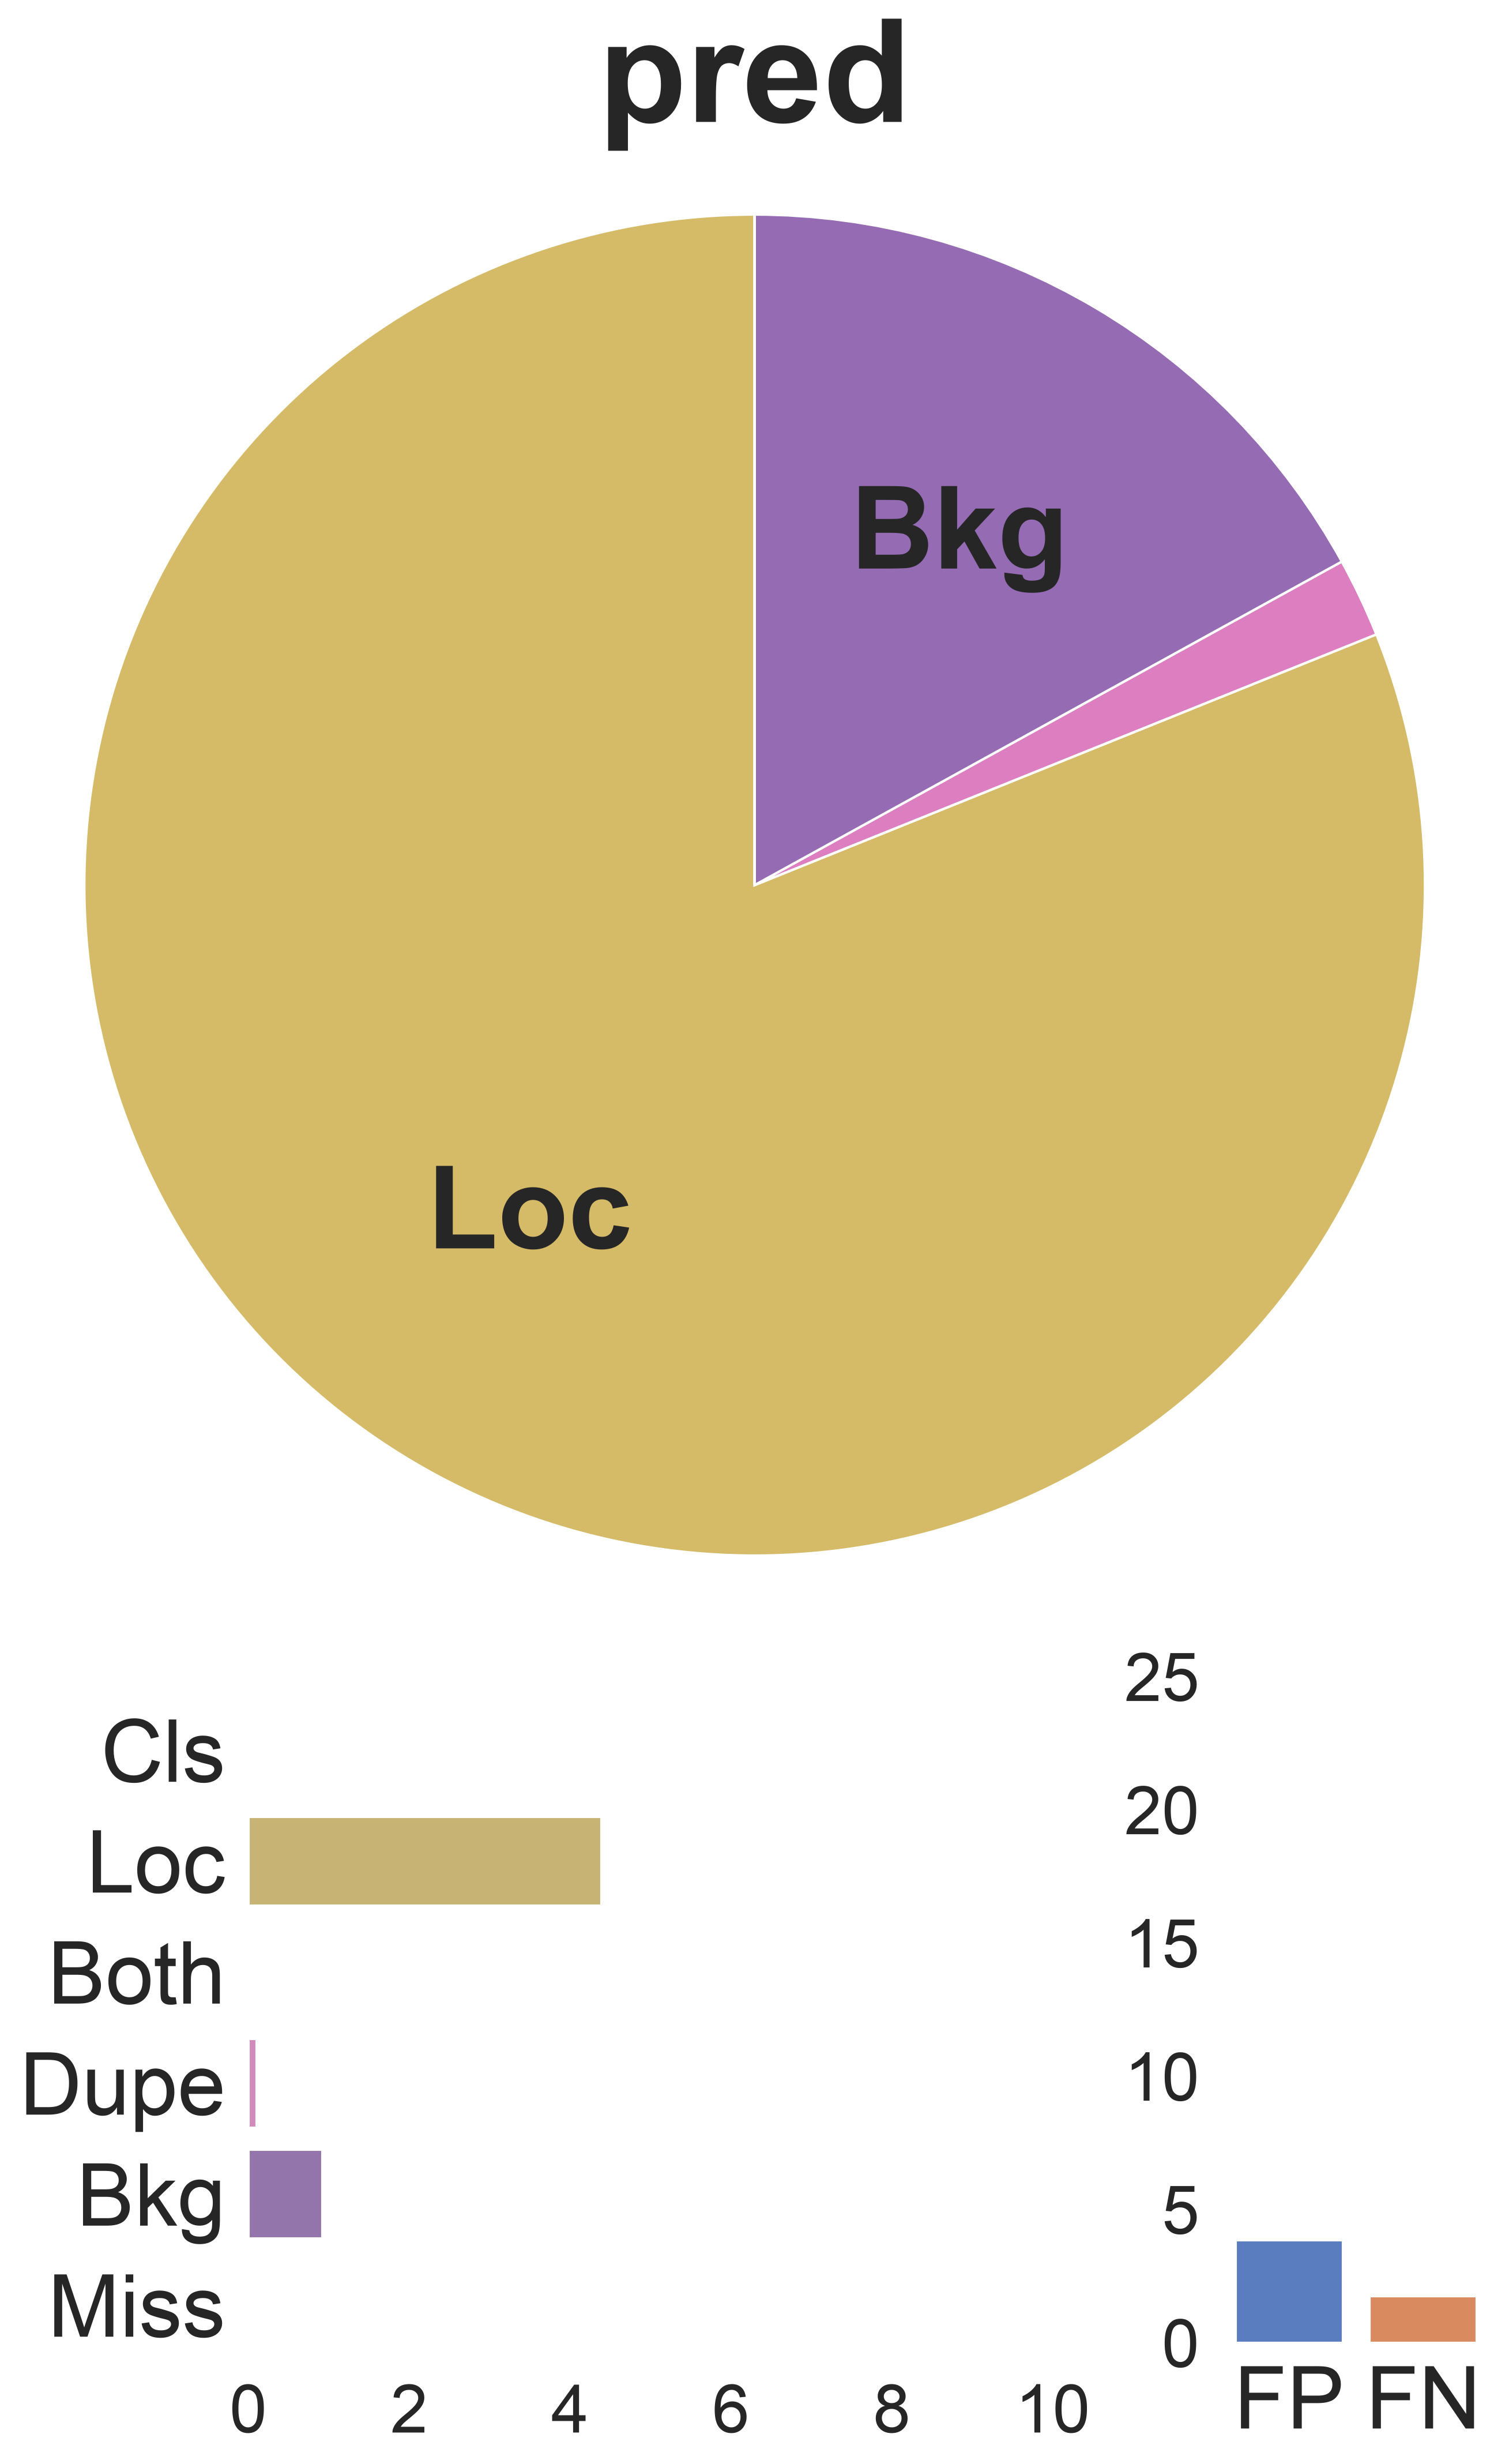

In [6]:

# =========================
# PATH
# =========================
MODEL = "/Users/mac/MeterReadAI/models_baseline/yolo11n-seg/merge-dataset/results/runs/segment/train/weights/best.pt"
DATASET = "/Users/mac/MeterReadAI/data/DataForTrain/ocr_water_meter"

IMAGES = f"{DATASET}/images/test"
LABELS = f"{DATASET}/labels/test"

GT_JSON = f"{DATASET}/gt.json"
PRED_JSON = f"{DATASET}/pred.json"

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL)

# =========================
# COCO STRUCTURE
# =========================
categories = [
    {"id": 1, "name": "object"}
]

gt = {
    "images": [],
    "annotations": [],
    "categories": categories
}

pred = []

ann_id = 1

# =========================
# PROCESS TEST IMAGES
# =========================
image_files = [
    f for f in os.listdir(IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_id, filename in enumerate(image_files, 1):

    image_path = os.path.join(IMAGES, filename)
    label_path = os.path.join(
        LABELS,
        os.path.splitext(filename)[0] + ".txt"
    )

    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    gt["images"].append({
        "id": image_id,
        "file_name": filename,
        "width": w,
        "height": h
    })

    # =========================
    # GROUND TRUTH
    # =========================
    if os.path.exists(label_path):

        with open(label_path) as f:

            for line in f:
                values = list(map(float, line.split()))
                if len(values) < 7:
                    continue

                cls = int(values[0])
                points = values[1:]

                polygon = []

                for i in range(0, len(points), 2):
                    polygon.extend([
                        points[i] * w,
                        points[i + 1] * h
                    ])

                # COCO bbox
                xs = polygon[0::2]
                ys = polygon[1::2]

                x_min = min(xs)
                y_min = min(ys)
                x_max = max(xs)
                y_max = max(ys)

                bbox = [
                    x_min,
                    y_min,
                    x_max - x_min,
                    y_max - y_min
                ]

                # Polygon -> RLE
                poly = [polygon]

                rles = mask_utils.frPyObjects(
                    poly,
                    h,
                    w
                )

                rle = mask_utils.merge(rles)

                area = float(mask_utils.area(rle))

                gt["annotations"].append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": 1,
                    "segmentation": poly,
                    "area": area,
                    "bbox": bbox,
                    "iscrowd": 0
                })

                ann_id += 1

    # =========================
    # YOLO PREDICTION
    # =========================
    result = model.predict(
        image_path,
        conf=0.001,
        verbose=False
    )[0]

    if result.masks is None:
        continue

    for i, polygon in enumerate(result.masks.xy):

        polygon = polygon.astype(float)

        flat = polygon.flatten().tolist()

        if len(flat) < 6:
            continue

        xs = polygon[:, 0]
        ys = polygon[:, 1]

        x_min = float(xs.min())
        y_min = float(xs.min())
        x_max = float(xs.max())
        y_max = float(ys.max())

        bbox = [
            x_min,
            y_min,
            x_max - x_min,
            y_max - y_min
        ]

        # Convert polygon prediction to RLE for TIDE Mask evaluation
        rle = mask_utils.frPyObjects([flat], h, w)[0]
        rle["counts"] = rle["counts"].decode("utf-8")

        pred.append({
            "image_id": image_id,
            "category_id": 1,
            "segmentation": rle,
            "bbox": bbox,
            "score": float(result.boxes.conf[i])
        })


# =========================
# SAVE COCO JSON
# =========================
with open(GT_JSON, "w") as f:
    json.dump(gt, f)

with open(PRED_JSON, "w") as f:
    json.dump(pred, f)

print("COCO JSON created!")

# =========================
# TIDE
# =========================
gt_data = datasets.COCO(GT_JSON)
pred_data = datasets.COCOResult(PRED_JSON)

tide = TIDE()

tide.evaluate(
    gt_data,
    pred_data,
    mode=TIDE.MASK
)

tide.summarize()
tide.plot(
    out_dir=f"{DATASET}/tide_results"
)

# Render generated plots directly inside Jupyter Notebook cell output
for img_path in glob.glob(f"{DATASET}/tide_results/*.png"):
    display(Image(filename=img_path))



COCO JSON created!
-- pred --

mask AP @ 50: 99.98

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     0.00     0.00     0.00     0.02     0.00  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       0.02       0.00  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

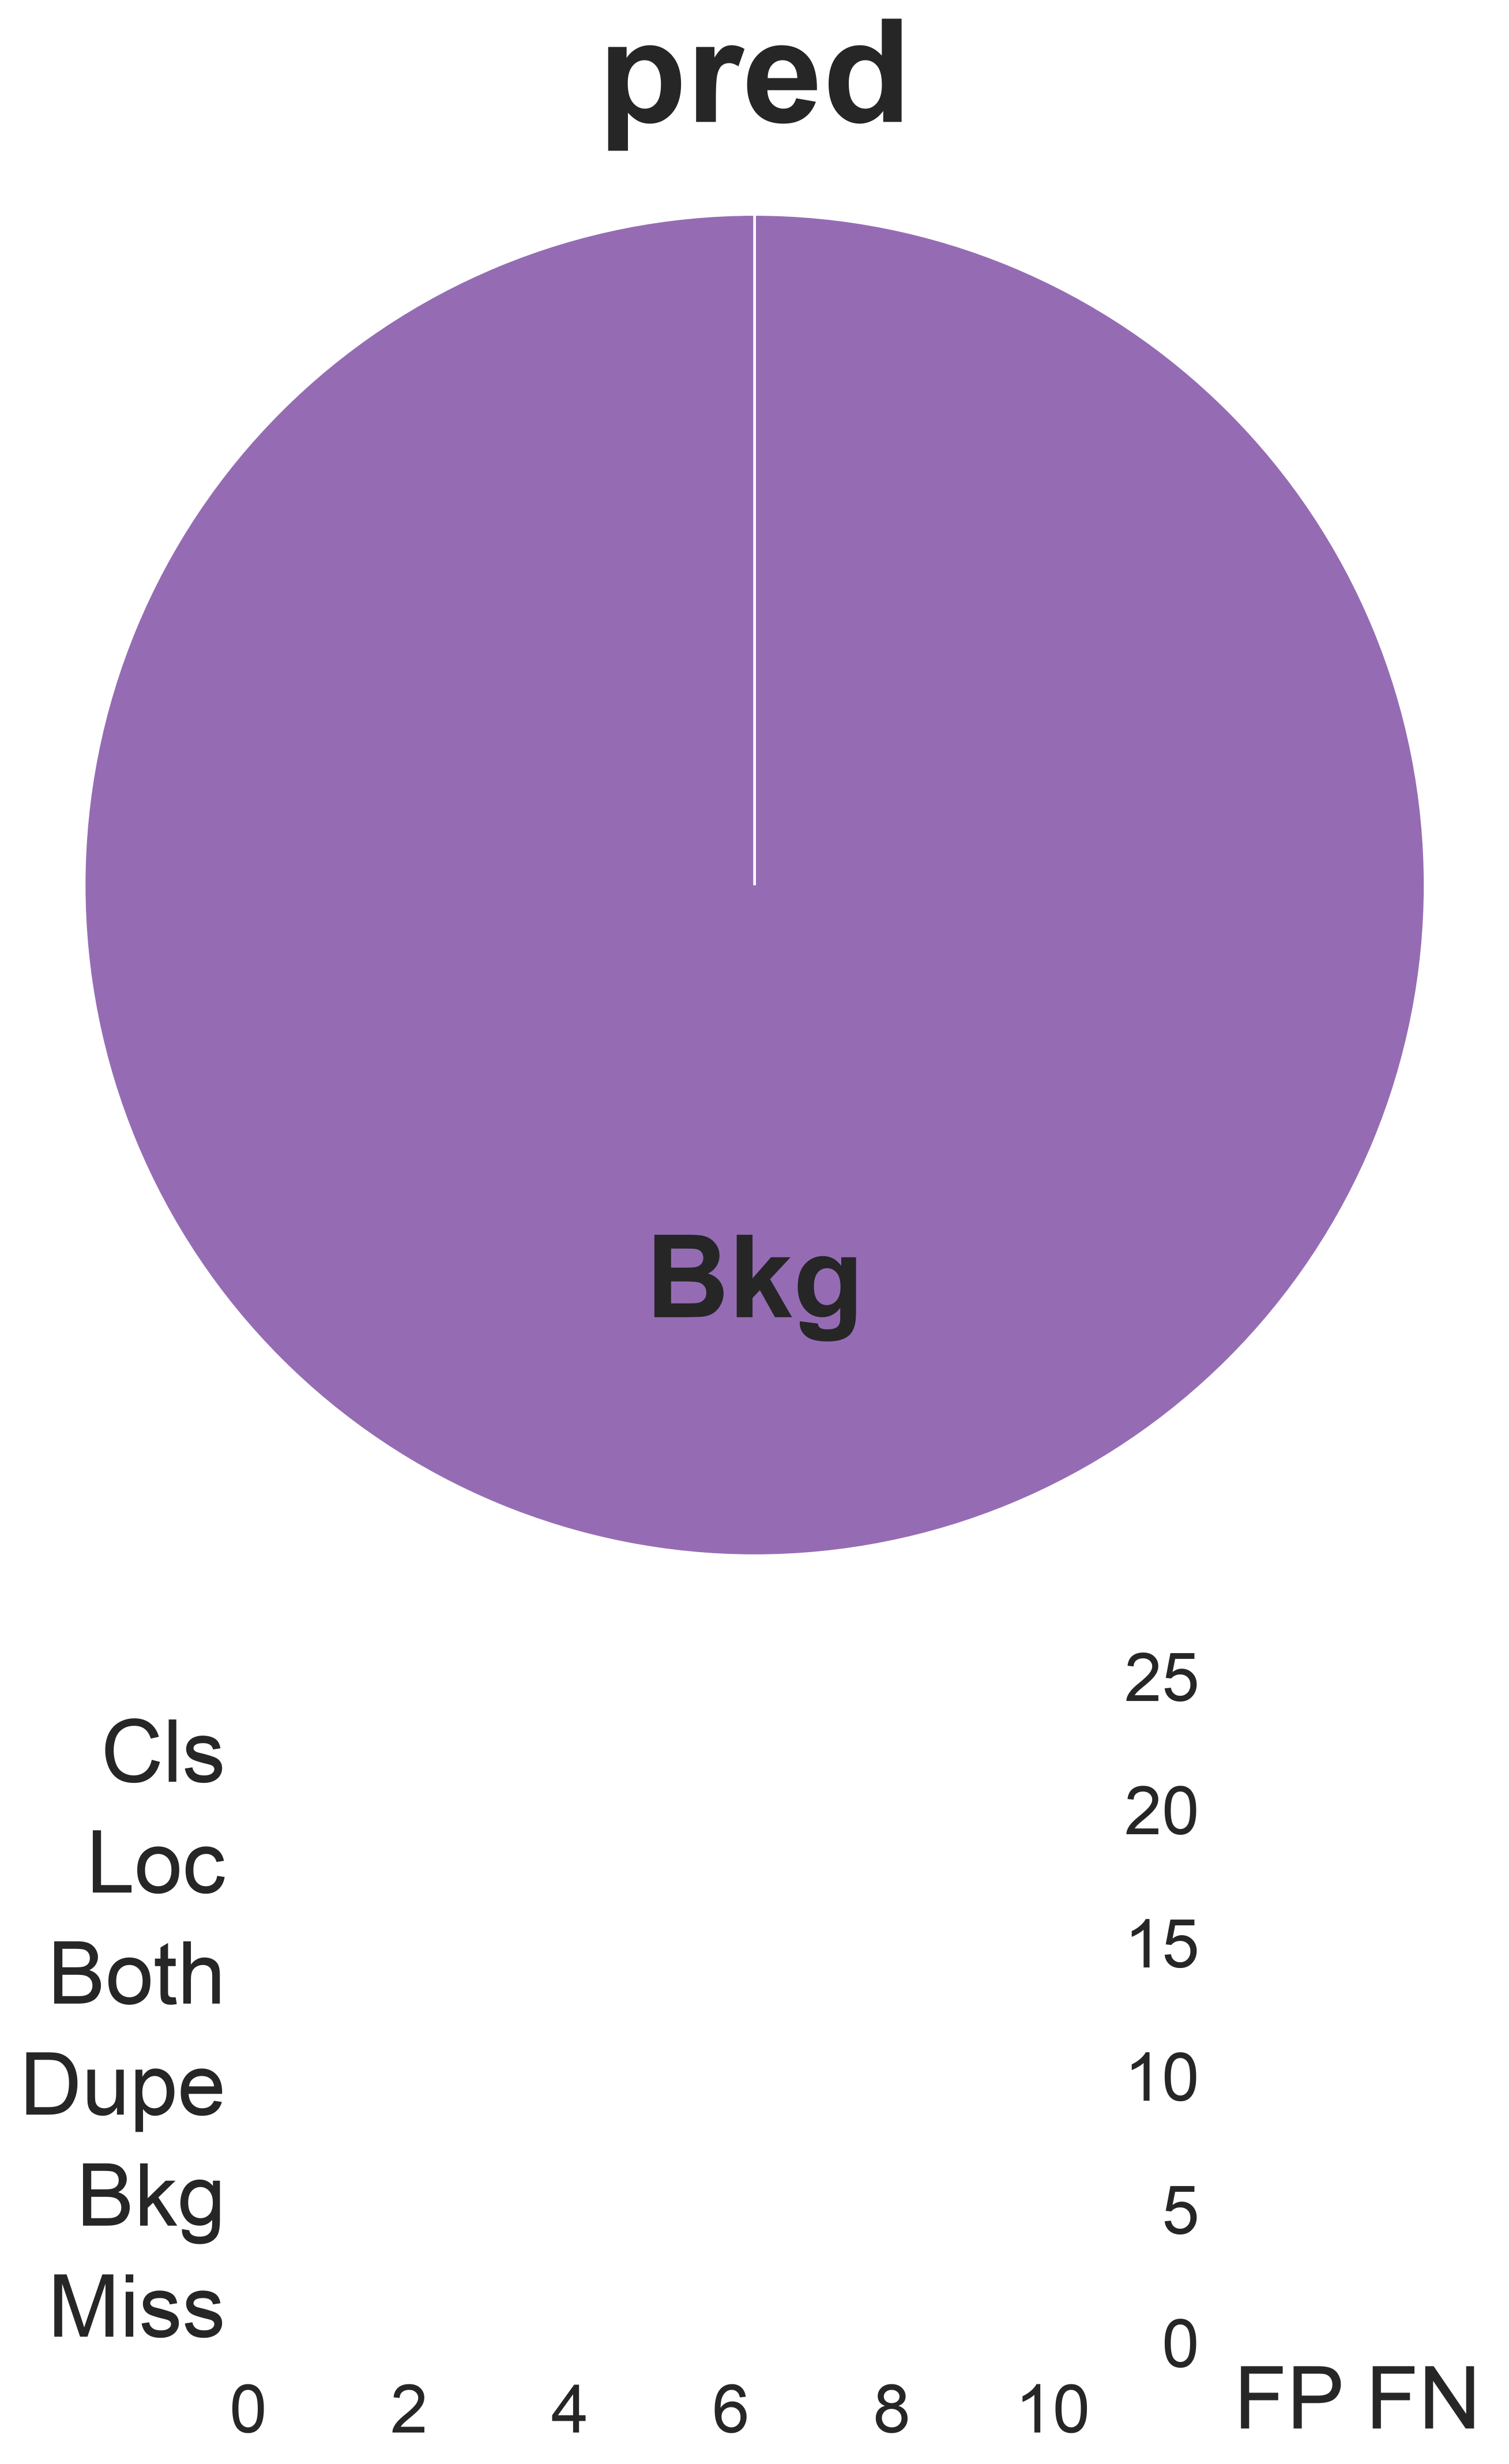

In [7]:

MODEL = "/Users/mac/MeterReadAI/models_baseline/yolo11n-seg/merge-dataset/results/runs/segment/train/weights/best.pt"
DATASET = "/Users/mac/MeterReadAI/data/DataForTrain/water_meters"

IMAGES = f"{DATASET}/images/test"
LABELS = f"{DATASET}/labels/test"

GT_JSON = f"{DATASET}/gt.json"
PRED_JSON = f"{DATASET}/pred.json"

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL)

# =========================
# COCO STRUCTURE
# =========================
categories = [
    {"id": 1, "name": "object"}
]

gt = {
    "images": [],
    "annotations": [],
    "categories": categories
}

pred = []

ann_id = 1

# =========================
# PROCESS TEST IMAGES
# =========================
image_files = [
    f for f in os.listdir(IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_id, filename in enumerate(image_files, 1):

    image_path = os.path.join(IMAGES, filename)
    label_path = os.path.join(
        LABELS,
        os.path.splitext(filename)[0] + ".txt"
    )

    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    gt["images"].append({
        "id": image_id,
        "file_name": filename,
        "width": w,
        "height": h
    })

    # =========================
    # GROUND TRUTH
    # =========================
    if os.path.exists(label_path):

        with open(label_path) as f:

            for line in f:
                values = list(map(float, line.split()))
                if len(values) < 7:
                    continue

                cls = int(values[0])
                points = values[1:]

                polygon = []

                for i in range(0, len(points), 2):
                    polygon.extend([
                        points[i] * w,
                        points[i + 1] * h
                    ])

                # COCO bbox
                xs = polygon[0::2]
                ys = polygon[1::2]

                x_min = min(xs)
                y_min = min(ys)
                x_max = max(xs)
                y_max = max(ys)

                bbox = [
                    x_min,
                    y_min,
                    x_max - x_min,
                    y_max - y_min
                ]

                # Polygon -> RLE
                poly = [polygon]

                rles = mask_utils.frPyObjects(
                    poly,
                    h,
                    w
                )

                rle = mask_utils.merge(rles)

                area = float(mask_utils.area(rle))

                gt["annotations"].append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": 1,
                    "segmentation": poly,
                    "area": area,
                    "bbox": bbox,
                    "iscrowd": 0
                })

                ann_id += 1

    # =========================
    # YOLO PREDICTION
    # =========================
    result = model.predict(
        image_path,
        conf=0.001,
        verbose=False
    )[0]

    if result.masks is None:
        continue

    for i, polygon in enumerate(result.masks.xy):

        polygon = polygon.astype(float)

        flat = polygon.flatten().tolist()

        if len(flat) < 6:
            continue

        xs = polygon[:, 0]
        ys = polygon[:, 1]

        x_min = float(xs.min())
        y_min = float(xs.min())
        x_max = float(xs.max())
        y_max = float(ys.max())

        bbox = [
            x_min,
            y_min,
            x_max - x_min,
            y_max - y_min
        ]

        # Convert polygon prediction to RLE for TIDE Mask evaluation
        rle = mask_utils.frPyObjects([flat], h, w)[0]
        rle["counts"] = rle["counts"].decode("utf-8")

        pred.append({
            "image_id": image_id,
            "category_id": 1,
            "segmentation": rle,
            "bbox": bbox,
            "score": float(result.boxes.conf[i])
        })


# =========================
# SAVE COCO JSON
# =========================
with open(GT_JSON, "w") as f:
    json.dump(gt, f)

with open(PRED_JSON, "w") as f:
    json.dump(pred, f)

print("COCO JSON created!")

# =========================
# TIDE
# =========================
gt_data = datasets.COCO(GT_JSON)
pred_data = datasets.COCOResult(PRED_JSON)

tide = TIDE()

tide.evaluate(
    gt_data,
    pred_data,
    mode=TIDE.MASK
)

tide.summarize()
tide.plot(
    out_dir=f"{DATASET}/tide_results"
)

# Render generated plots directly inside Jupyter Notebook cell output
for img_path in glob.glob(f"{DATASET}/tide_results/*.png"):
    display(Image(filename=img_path))



COCO JSON created!
-- pred --

mask AP @ 50: 99.79

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     0.00     0.00     0.00     0.20     0.00  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       0.21       0.00  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

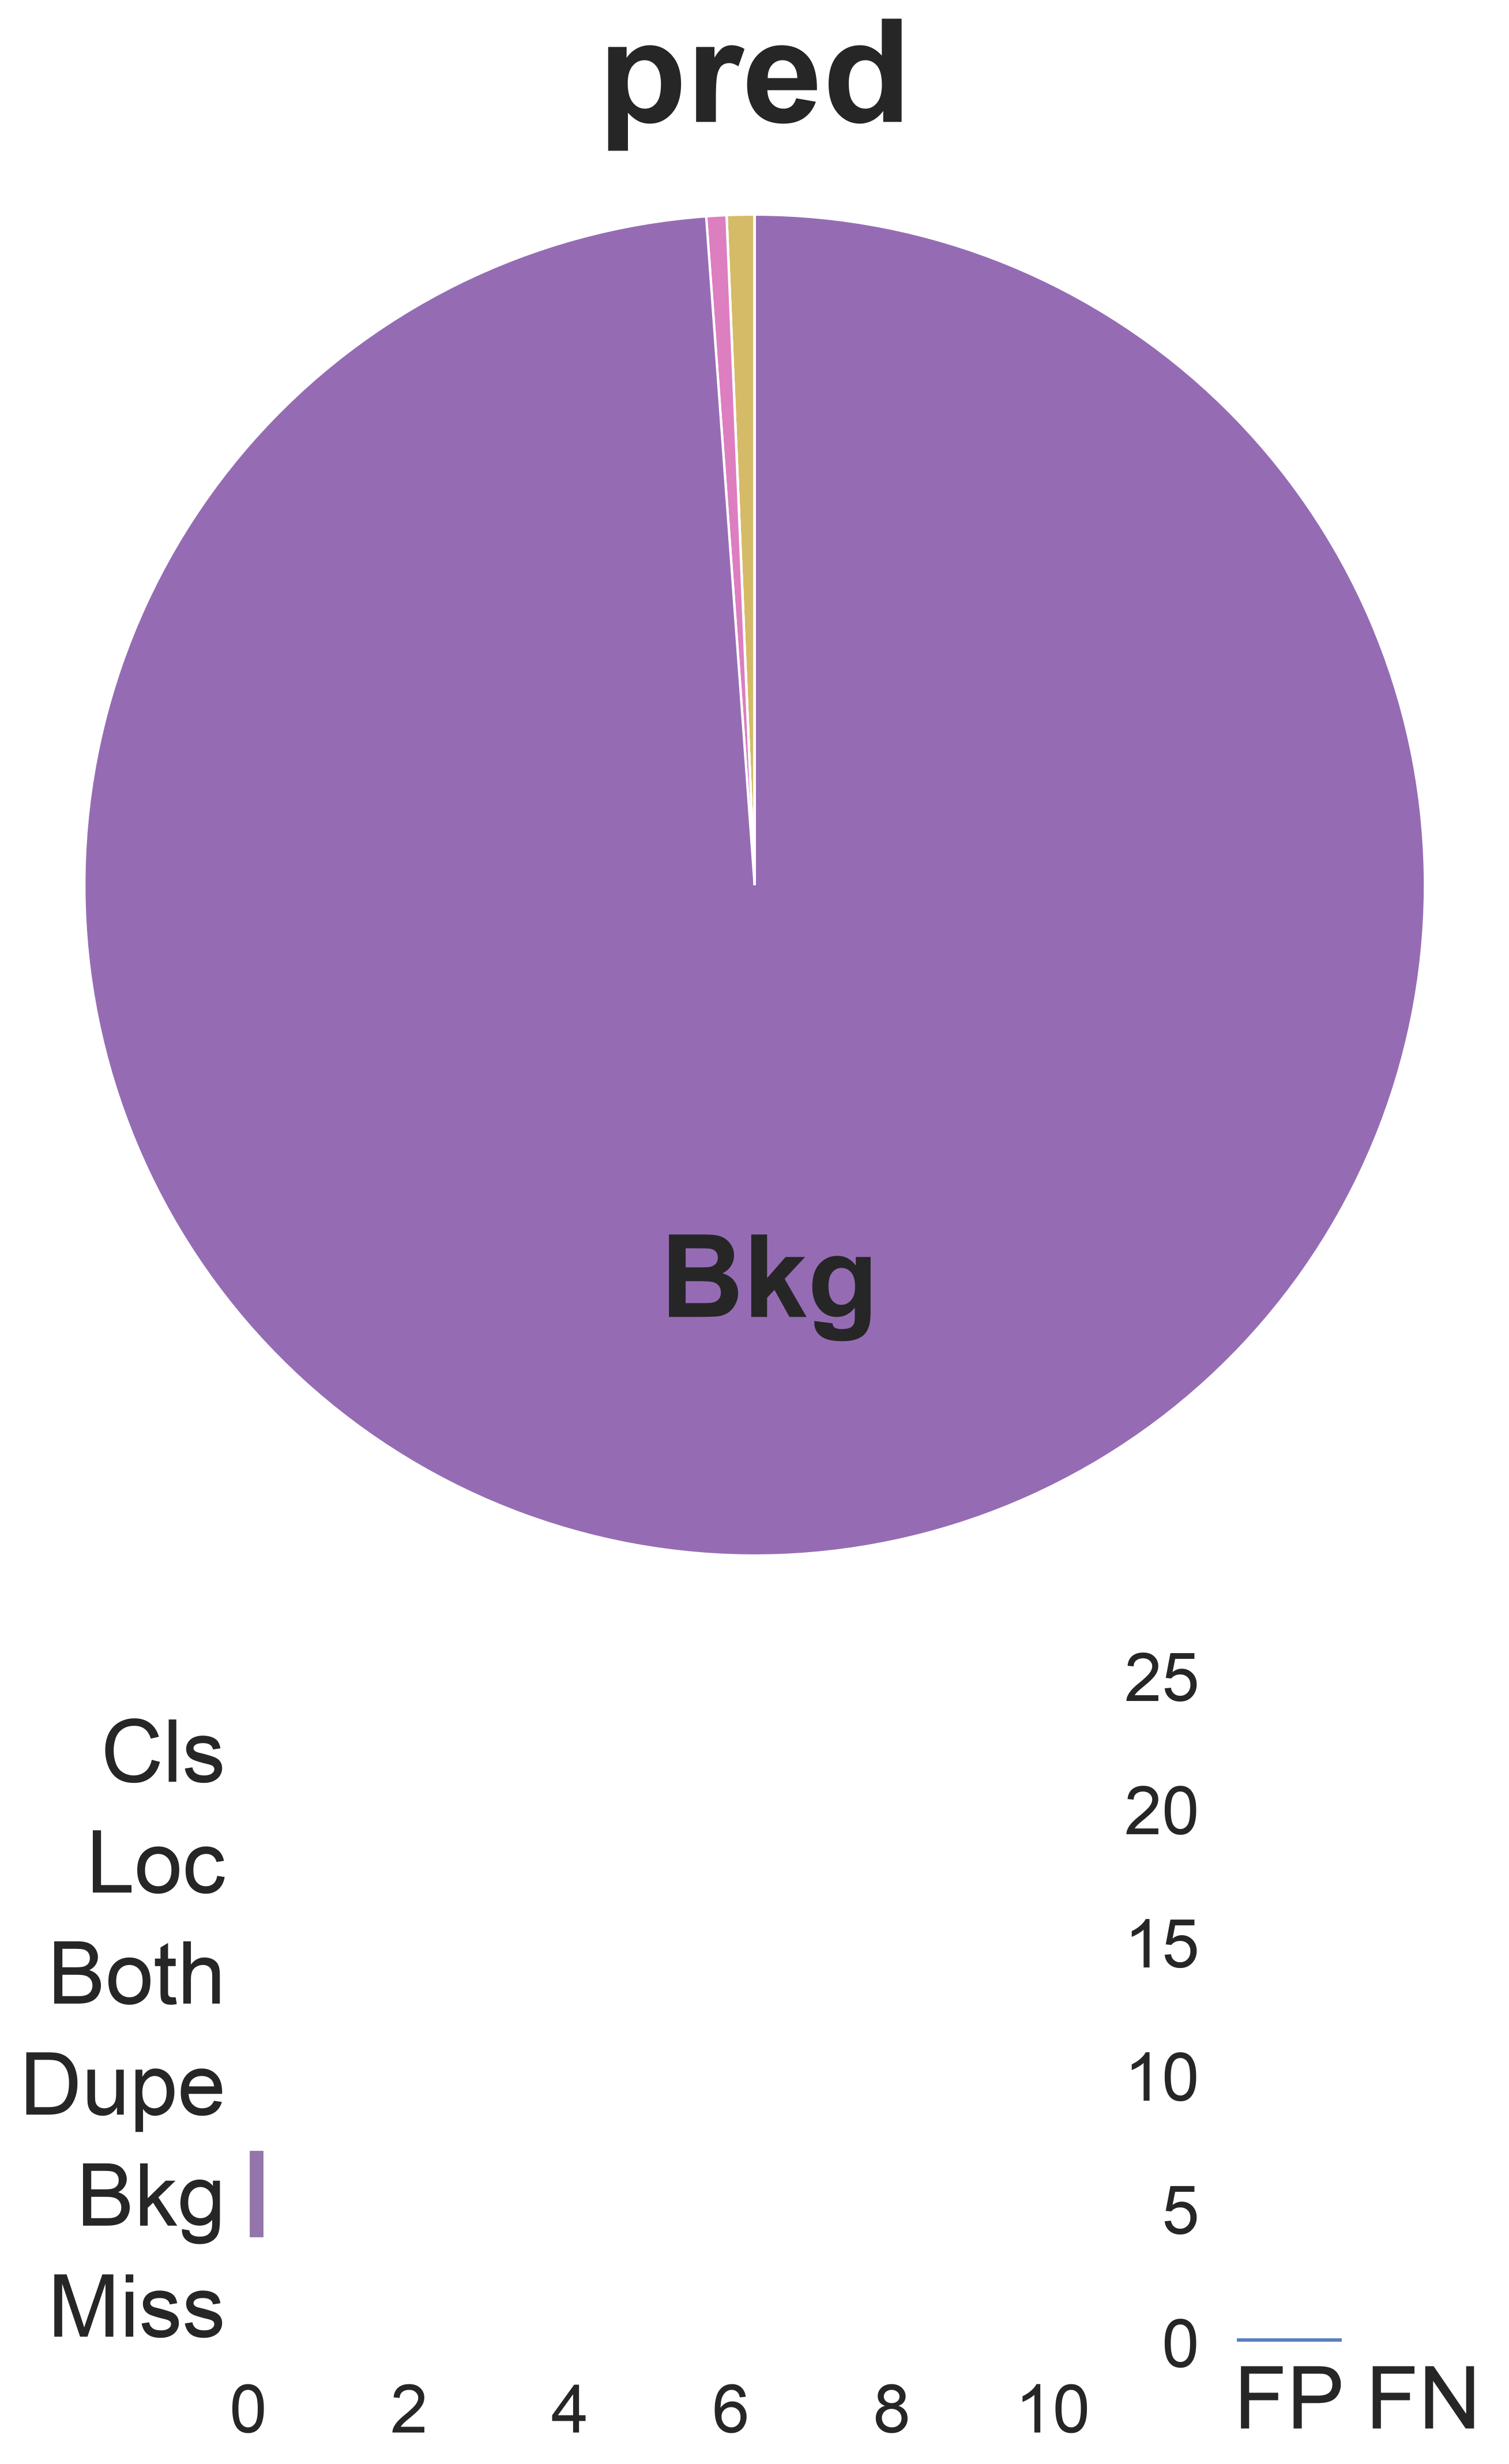

In [8]:

MODEL = "/Users/mac/MeterReadAI/models_baseline/yolo11n-seg/merge-dataset/results/runs/segment/train/weights/best.pt"
DATASET = "/Users/mac/MeterReadAI/data/DataForTrain/word_wheel_water_meter"

IMAGES = f"{DATASET}/images/test"
LABELS = f"{DATASET}/labels/test"

GT_JSON = f"{DATASET}/gt.json"
PRED_JSON = f"{DATASET}/pred.json"

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL)

# =========================
# COCO STRUCTURE
# =========================
categories = [
    {"id": 1, "name": "object"}
]

gt = {
    "images": [],
    "annotations": [],
    "categories": categories
}

pred = []

ann_id = 1

# =========================
# PROCESS TEST IMAGES
# =========================
image_files = [
    f for f in os.listdir(IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_id, filename in enumerate(image_files, 1):

    image_path = os.path.join(IMAGES, filename)
    label_path = os.path.join(
        LABELS,
        os.path.splitext(filename)[0] + ".txt"
    )

    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    gt["images"].append({
        "id": image_id,
        "file_name": filename,
        "width": w,
        "height": h
    })

    # =========================
    # GROUND TRUTH
    # =========================
    if os.path.exists(label_path):

        with open(label_path) as f:

            for line in f:
                values = list(map(float, line.split()))
                if len(values) < 7:
                    continue

                cls = int(values[0])
                points = values[1:]

                polygon = []

                for i in range(0, len(points), 2):
                    polygon.extend([
                        points[i] * w,
                        points[i + 1] * h
                    ])

                # COCO bbox
                xs = polygon[0::2]
                ys = polygon[1::2]

                x_min = min(xs)
                y_min = min(ys)
                x_max = max(xs)
                y_max = max(ys)

                bbox = [
                    x_min,
                    y_min,
                    x_max - x_min,
                    y_max - y_min
                ]

                # Polygon -> RLE
                poly = [polygon]

                rles = mask_utils.frPyObjects(
                    poly,
                    h,
                    w
                )

                rle = mask_utils.merge(rles)

                area = float(mask_utils.area(rle))

                gt["annotations"].append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": 1,
                    "segmentation": poly,
                    "area": area,
                    "bbox": bbox,
                    "iscrowd": 0
                })

                ann_id += 1

    # =========================
    # YOLO PREDICTION
    # =========================
    result = model.predict(
        image_path,
        conf=0.001,
        verbose=False
    )[0]

    if result.masks is None:
        continue

    for i, polygon in enumerate(result.masks.xy):

        polygon = polygon.astype(float)

        flat = polygon.flatten().tolist()

        if len(flat) < 6:
            continue

        xs = polygon[:, 0]
        ys = polygon[:, 1]

        x_min = float(xs.min())
        y_min = float(xs.min())
        x_max = float(xs.max())
        y_max = float(ys.max())

        bbox = [
            x_min,
            y_min,
            x_max - x_min,
            y_max - y_min
        ]

        # Convert polygon prediction to RLE for TIDE Mask evaluation
        rle = mask_utils.frPyObjects([flat], h, w)[0]
        rle["counts"] = rle["counts"].decode("utf-8")

        pred.append({
            "image_id": image_id,
            "category_id": 1,
            "segmentation": rle,
            "bbox": bbox,
            "score": float(result.boxes.conf[i])
        })


# =========================
# SAVE COCO JSON
# =========================
with open(GT_JSON, "w") as f:
    json.dump(gt, f)

with open(PRED_JSON, "w") as f:
    json.dump(pred, f)

print("COCO JSON created!")

# =========================
# TIDE
# =========================
gt_data = datasets.COCO(GT_JSON)
pred_data = datasets.COCOResult(PRED_JSON)

tide = TIDE()

tide.evaluate(
    gt_data,
    pred_data,
    mode=TIDE.MASK
)

tide.summarize()
tide.plot(
    out_dir=f"{DATASET}/tide_results"
)

# Render generated plots directly inside Jupyter Notebook cell output
for img_path in glob.glob(f"{DATASET}/tide_results/*.png"):
    display(Image(filename=img_path))



COCO JSON created!
-- pred --

mask AP @ 50: 98.92

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     0.43     0.00     0.00     0.04     0.00  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       0.09       0.37  



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['main'], x='Delta mAP', y='Error Type', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=error_dfs['special'], x='Error Type', y='Delta mAP', ax=ax,
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tidecv/plotting.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  a

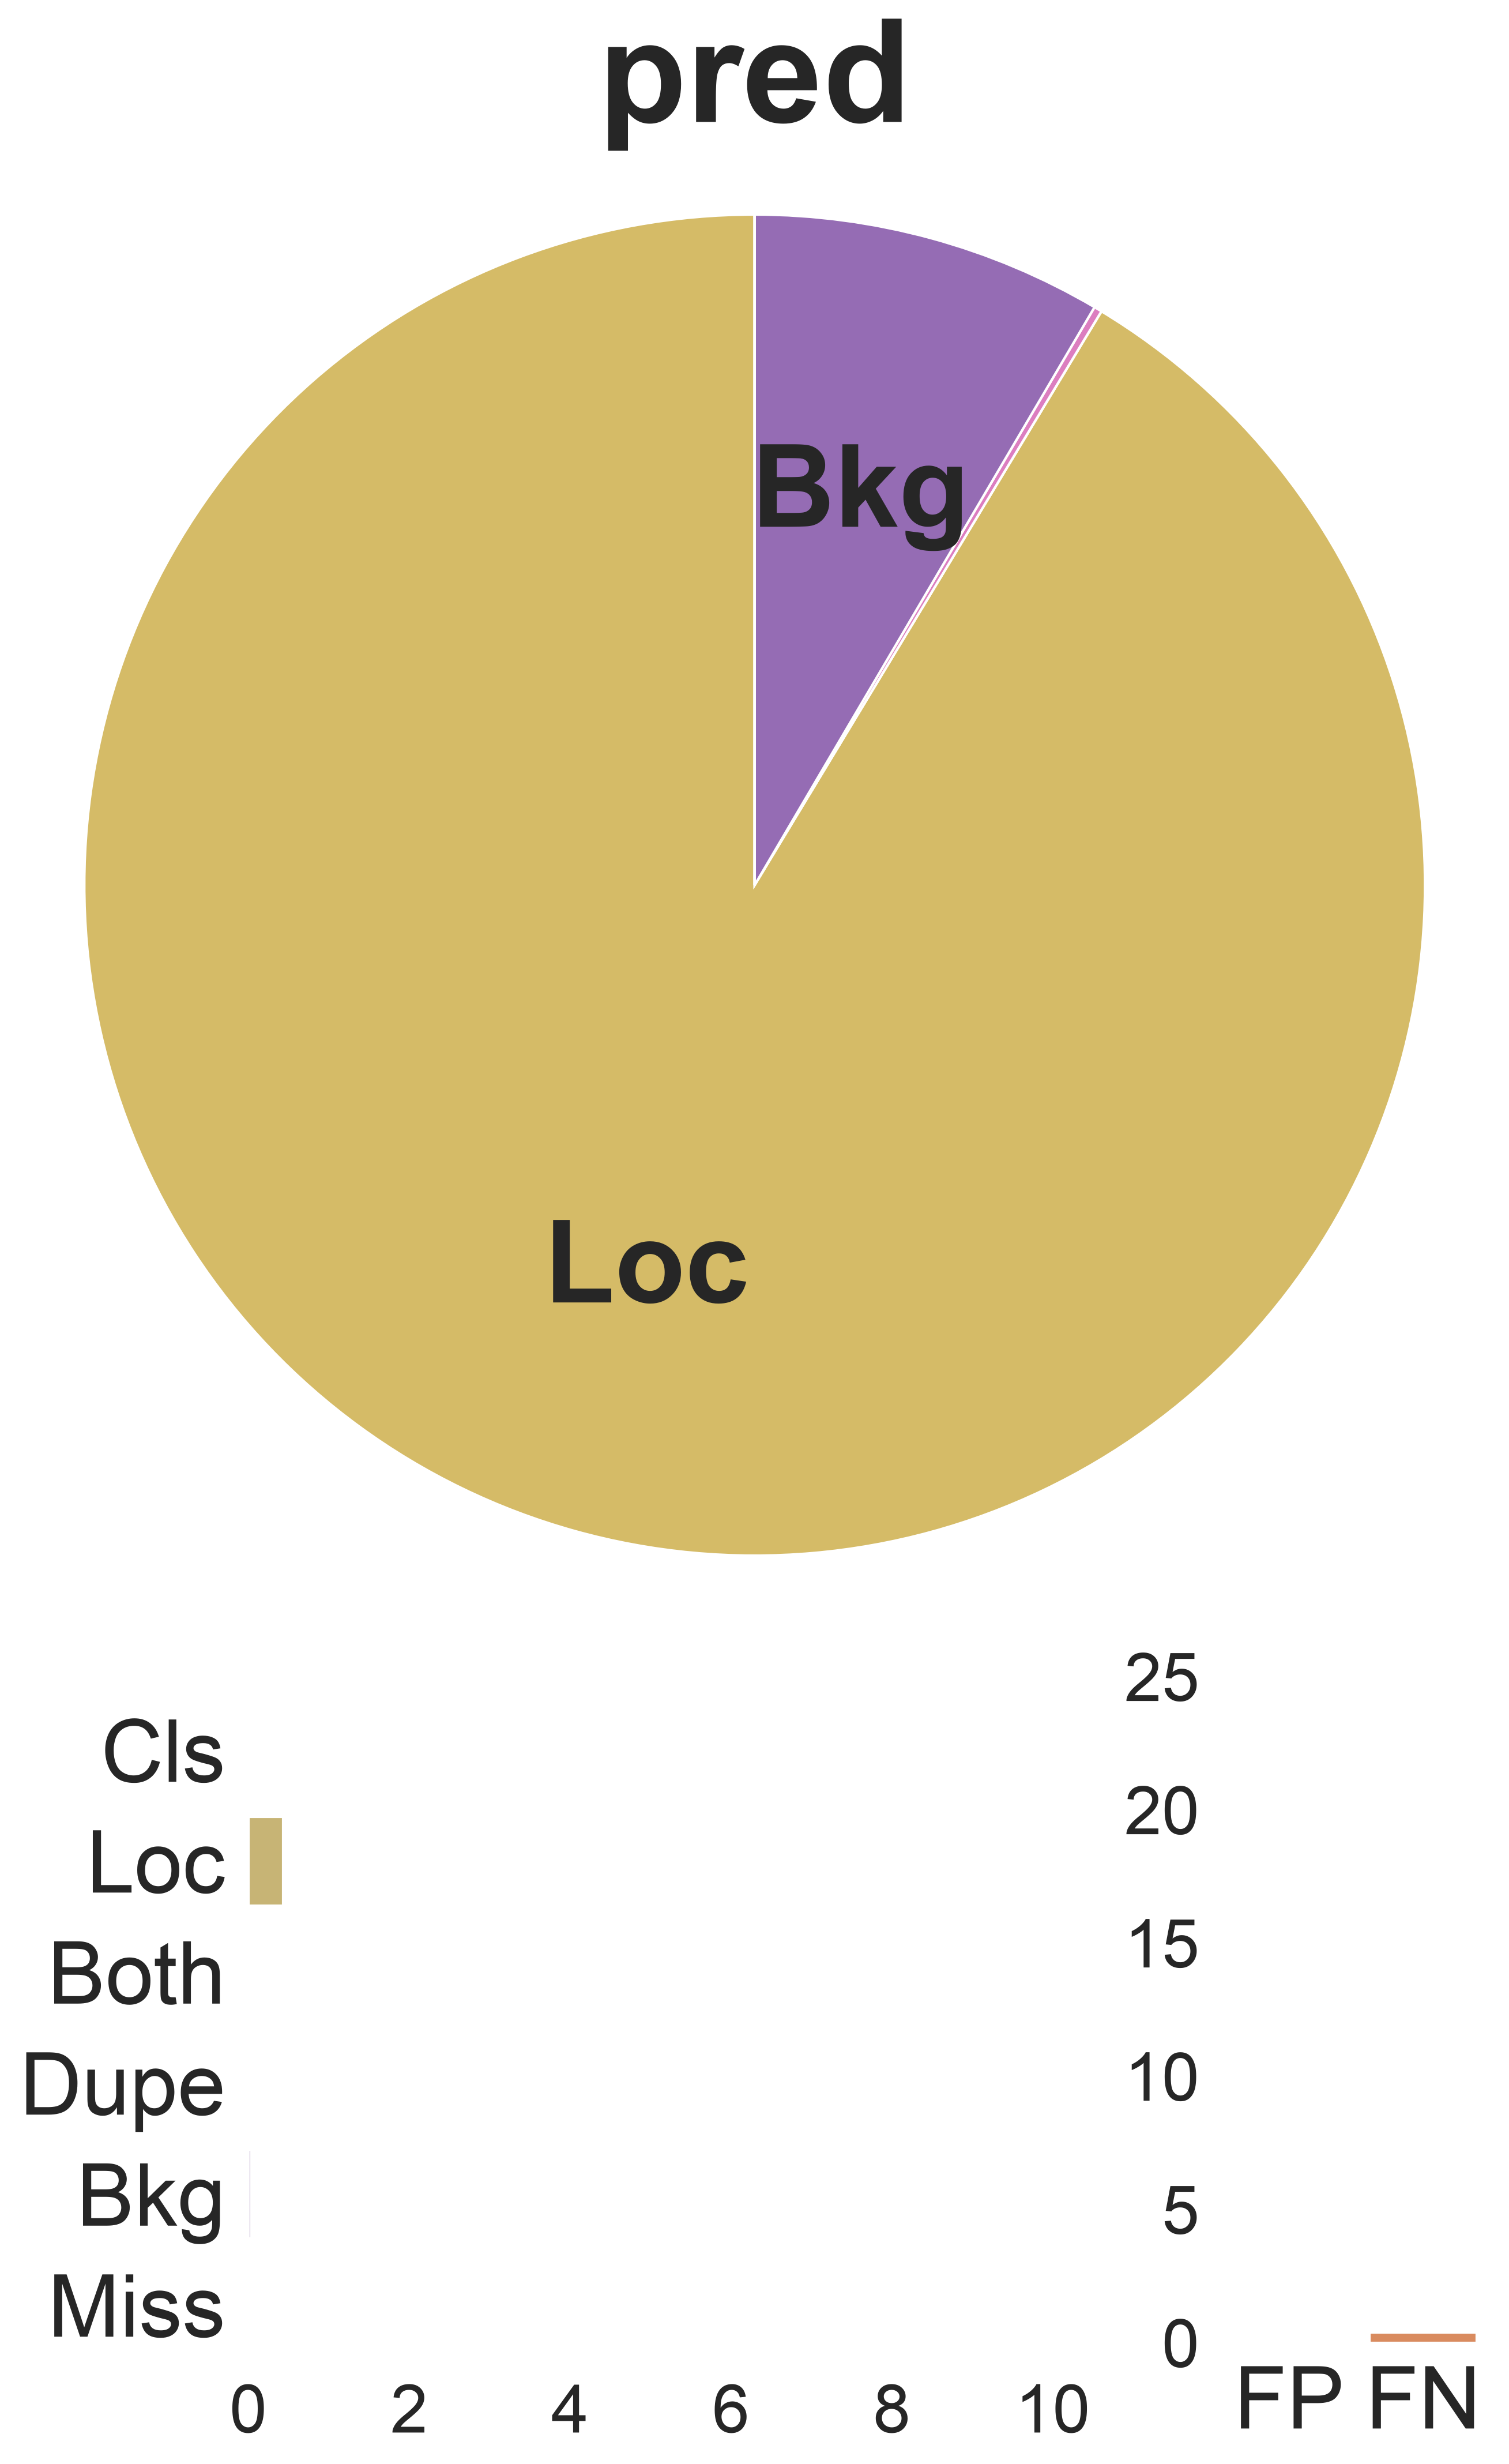

In [9]:

MODEL = "/Users/mac/MeterReadAI/models_baseline/yolo11n-seg/merge-dataset/results/runs/segment/train/weights/best.pt"
DATASET = "/Users/mac/MeterReadAI/data/DataForTrain/merge_dataset"

IMAGES = f"{DATASET}/images/test"
LABELS = f"{DATASET}/labels/test"

GT_JSON = f"{DATASET}/gt.json"
PRED_JSON = f"{DATASET}/pred.json"

# =========================
# LOAD MODEL
# =========================
model = YOLO(MODEL)

# =========================
# COCO STRUCTURE
# =========================
categories = [
    {"id": 1, "name": "object"}
]

gt = {
    "images": [],
    "annotations": [],
    "categories": categories
}

pred = []

ann_id = 1

# =========================
# PROCESS TEST IMAGES
# =========================
image_files = [
    f for f in os.listdir(IMAGES)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for image_id, filename in enumerate(image_files, 1):

    image_path = os.path.join(IMAGES, filename)
    label_path = os.path.join(
        LABELS,
        os.path.splitext(filename)[0] + ".txt"
    )

    img = cv2.imread(image_path)
    if img is None:
        continue
    h, w = img.shape[:2]

    gt["images"].append({
        "id": image_id,
        "file_name": filename,
        "width": w,
        "height": h
    })

    # =========================
    # GROUND TRUTH
    # =========================
    if os.path.exists(label_path):

        with open(label_path) as f:

            for line in f:
                values = list(map(float, line.split()))
                if len(values) < 7:
                    continue

                cls = int(values[0])
                points = values[1:]

                polygon = []

                for i in range(0, len(points), 2):
                    polygon.extend([
                        points[i] * w,
                        points[i + 1] * h
                    ])

                # COCO bbox
                xs = polygon[0::2]
                ys = polygon[1::2]

                x_min = min(xs)
                y_min = min(ys)
                x_max = max(xs)
                y_max = max(ys)

                bbox = [
                    x_min,
                    y_min,
                    x_max - x_min,
                    y_max - y_min
                ]

                # Polygon -> RLE
                poly = [polygon]

                rles = mask_utils.frPyObjects(
                    poly,
                    h,
                    w
                )

                rle = mask_utils.merge(rles)

                area = float(mask_utils.area(rle))

                gt["annotations"].append({
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": 1,
                    "segmentation": poly,
                    "area": area,
                    "bbox": bbox,
                    "iscrowd": 0
                })

                ann_id += 1

    # =========================
    # YOLO PREDICTION
    # =========================
    result = model.predict(
        image_path,
        conf=0.001,
        verbose=False
    )[0]

    if result.masks is None:
        continue

    for i, polygon in enumerate(result.masks.xy):

        polygon = polygon.astype(float)

        flat = polygon.flatten().tolist()

        if len(flat) < 6:
            continue

        xs = polygon[:, 0]
        ys = polygon[:, 1]

        x_min = float(xs.min())
        y_min = float(xs.min())
        x_max = float(xs.max())
        y_max = float(ys.max())

        bbox = [
            x_min,
            y_min,
            x_max - x_min,
            y_max - y_min
        ]

        # Convert polygon prediction to RLE for TIDE Mask evaluation
        rle = mask_utils.frPyObjects([flat], h, w)[0]
        rle["counts"] = rle["counts"].decode("utf-8")

        pred.append({
            "image_id": image_id,
            "category_id": 1,
            "segmentation": rle,
            "bbox": bbox,
            "score": float(result.boxes.conf[i])
        })


# =========================
# SAVE COCO JSON
# =========================
with open(GT_JSON, "w") as f:
    json.dump(gt, f)

with open(PRED_JSON, "w") as f:
    json.dump(pred, f)

print("COCO JSON created!")

# =========================
# TIDE
# =========================
gt_data = datasets.COCO(GT_JSON)
pred_data = datasets.COCOResult(PRED_JSON)

tide = TIDE()

tide.evaluate(
    gt_data,
    pred_data,
    mode=TIDE.MASK
)

tide.summarize()
tide.plot(
    out_dir=f"{DATASET}/tide_results"
)

# Render generated plots directly inside Jupyter Notebook cell output
for img_path in glob.glob(f"{DATASET}/tide_results/*.png"):
    display(Image(filename=img_path))

